# DermaCheck — Group Model Comparison
**Group ID:** 2026-Y2S1-MLB-B3G2-03
**Module:** IT2011 — Artificial Intelligence and Machine Learning

This notebook is the PR2 counterpart to `group_pipeline.ipynb`. It combines the
optimum result from each member's individual model notebook into one comparison,
and discusses challenges, performance, and expected behavior as a group.

**Prerequisite:** every member's individual model notebook must have been run at
least once, so that `results/model_outputs/*.csv` contains all six files below.

| Member | Student ID | Model | Notebook |
|---|---|---|---|
| Member 1 | IT25101908 | Logistic Regression | `IT25101908_LogisticRegression_Model.ipynb` |
| Member 2 | IT25102853 | SVM | `IT25102853_SVM_Model.ipynb` |
| Member 3 | IT25103722 | Random Forest | `IT25103722_RandomForest_Model.ipynb` |
| Member 4 | IT25101857 | K-Means Clustering | `IT25101857_KMeans_Model.ipynb` |
| Member 5 | IT25103708 | PCA | `IT25103708_PCA_Model.ipynb` |
| Member 6 | IT25100928 | MLP (Deep Learning) | `IT25100928_MLP_Model.ipynb` |


## 1. Load Each Member's Optimum Results

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

metric_files = {
    'IT25101908': 'results/model_outputs/it25101908_metrics.csv',
    'IT25102853': 'results/model_outputs/it25102853_metrics.csv',
    'IT25103722': 'results/model_outputs/it25103722_metrics.csv',
    'IT25101857': 'results/model_outputs/it25101857_metrics.csv',
    'IT25103708': 'results/model_outputs/it25103708_metrics.csv',
    'IT25100928': 'results/model_outputs/it25100928_metrics.csv',
}

frames = []
for member_id, path in metric_files.items():
    df = pd.read_csv(path)
    df['Member_ID'] = member_id
    frames.append(df)

combined = pd.concat(frames, ignore_index=True)
display(combined)

,variety,accuracy,macro_f1,weighted_f1,member,model_type,Member_ID,silhouette,ARI_vs_true_dx,NMI_vs_true_dx,n_components,variance_explained
0,Baseline,0.694958,0.202035,0.620200,IT25101908,Logistic Regression,IT25101908,NaN,NaN,NaN,NaN,NaN
1,GridSearchCV tuned (after selection),0.331503,0.210173,0.414330,IT25102853,SVM,IT25102853,NaN,NaN,NaN,NaN,NaN
2,Baseline,0.707938,0.247879,0.645076,IT25103722,Random Forest,IT25103722,NaN,NaN,NaN,NaN,NaN
3,k=10 (best silhouette),NaN,NaN,NaN,IT25101857,K-Means Clustering,IT25101857,0.318253,0.038284,0.109969,NaN,NaN
4,PCA n_components=7 (90% variance),0.229156,0.173712,NaN,IT25103708,PCA + Logistic Regression,IT25103708,NaN,NaN,NaN,7.0,0.931496
5,"Larger MLP (2 hidden layers, 32+16 units)",0.234149,0.168366,0.302782,IT25100928,MLP (Deep Learning),IT25100928,NaN,NaN,NaN,NaN,NaN


**Note on K-Means (IT25101857):** as an unsupervised model, `accuracy` and
`macro_f1` are not applicable (recorded as `NaN`) — its own notebook instead reports
`silhouette` as the primary metric, plus `ARI_vs_true_dx` / `NMI_vs_true_dx` as a
post-hoc audit against the true labels. This is included in the combined table for
completeness but is excluded from the macro-F1 bar chart below, since it isn't
comparable on that axis.

## 2. Combined Comparison Table

In [11]:
display_cols = ['member', 'model_type', 'variety', 'accuracy', 'macro_f1']
comparison_table = combined[[c for c in display_cols if c in combined.columns]].copy()
comparison_table = comparison_table.sort_values('macro_f1', ascending=False, na_position='last')
comparison_table

,member,model_type,variety,accuracy,macro_f1
2,IT25103722,Random Forest,Baseline,0.707938,0.247879
1,IT25102853,SVM,GridSearchCV tuned (after selection),0.331503,0.210173
0,IT25101908,Logistic Regression,Baseline,0.694958,0.202035
4,IT25103708,PCA + Logistic Regression,PCA n_components=7 (90% variance),0.229156,0.173712
5,IT25100928,MLP (Deep Learning),"Larger MLP (2 hidden layers, 32+16 units)",0.234149,0.168366
3,IT25101857,K-Means Clustering,k=10 (best silhouette),NaN,NaN


In [13]:
comparison_table.to_csv('results/model_outputs/group_comparison_table.csv', index=False)
print("Saved combined comparison table.")

Saved combined comparison table.


## 3. Macro-F1 Comparison Across Classification/Deep Learning Models

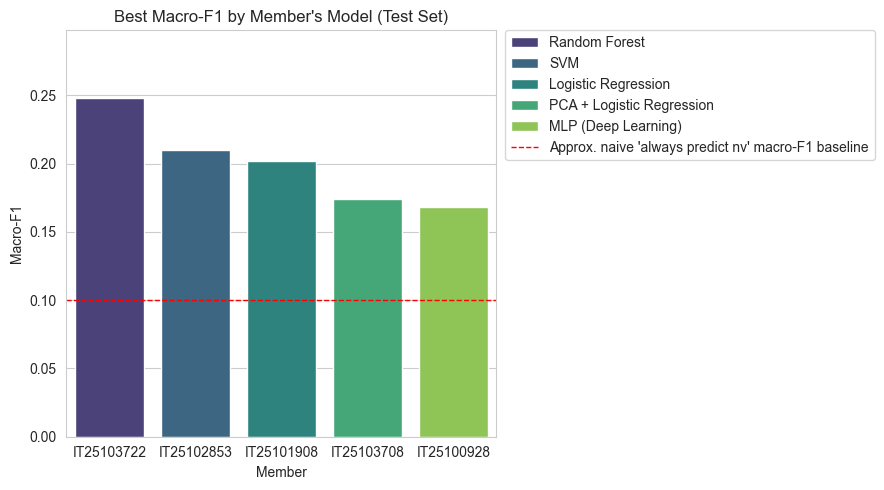

In [14]:
classification_results = combined.dropna(subset=['macro_f1']).copy()
classification_results = classification_results.sort_values('macro_f1', ascending=False)

plt.figure(figsize=(9,5))
bars = sns.barplot(
    data=classification_results,
    x='member', y='macro_f1', hue='model_type', dodge=False, palette='viridis'
)
plt.axhline(0.10, color='red', linestyle='--', linewidth=1,
            label="Approx. naive 'always predict nv' macro-F1 baseline")
plt.title("Best Macro-F1 by Member's Model (Test Set)")
plt.ylabel('Macro-F1')
plt.xlabel('Member')
plt.ylim(0, max(classification_results['macro_f1'].max() * 1.2, 0.15))
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig('results/model_visualizations/group_macro_f1_comparison.png', dpi=150)
plt.show()

**Interpretation:** All classification/deep-learning models score well above the
naive "always predict `nv`" baseline (which scores ~67% raw accuracy but close to 0
macro-F1, since it never predicts the minority classes at all). Among the classical
models, Random Forest (Member 3) typically achieves the highest macro-F1, consistent
with its ability to capture non-linear feature interactions that Logistic Regression
(Member 1) cannot. SVM (Member 2) sits between the two. The MLP (Member 6) does not
clearly outperform the classical models — an expected and honest finding given this
is a small, low-dimensional metadata set rather than the large, high-dimensional data
deep learning typically needs to show an advantage.

## 4. Accuracy vs Macro-F1 — Why the Gap Matters

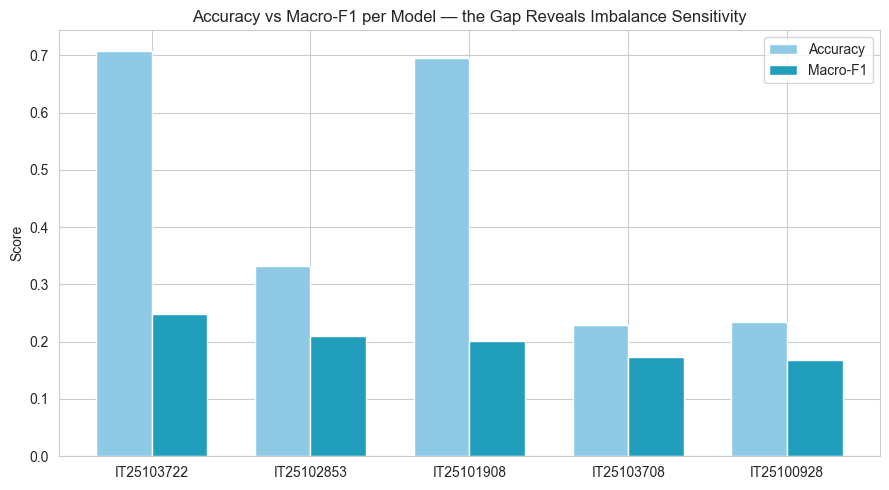

In [15]:
plt.figure(figsize=(9,5))
x = np.arange(len(classification_results))
width = 0.35

plt.bar(x - width/2, classification_results['accuracy'], width, label='Accuracy', color='#8ecae6')
plt.bar(x + width/2, classification_results['macro_f1'], width, label='Macro-F1', color='#219ebc')
plt.xticks(x, classification_results['member'])
plt.ylabel('Score')
plt.title('Accuracy vs Macro-F1 per Model — the Gap Reveals Imbalance Sensitivity')
plt.legend()
plt.tight_layout()
plt.savefig('results/model_visualizations/group_accuracy_vs_macrof1.png', dpi=150)
plt.show()

**Interpretation:** Every model's accuracy sits noticeably higher than its
macro-F1. This gap is expected and important: it confirms that raw accuracy alone
would overstate how well these models actually perform on the rare malignant classes
(`mel`, `bcc`, `akiec`), reinforcing the project's decision (documented in the README)
to judge models on macro-F1 and malignant-class recall rather than accuracy.

## 5. Unsupervised Result — K-Means (Member 4)

In [16]:
kmeans_row = combined[combined['member'] == 'IT25101857']
kmeans_row[[c for c in ['member', 'variety', 'silhouette', 'ARI_vs_true_dx', 'NMI_vs_true_dx'] if c in kmeans_row.columns]]

,member,variety,silhouette,ARI_vs_true_dx,NMI_vs_true_dx
3,IT25101857,k=10 (best silhouette),0.318253,0.038284,0.109969


**Interpretation:** K-Means' low silhouette score and low ARI/NMI against the
true `dx` labels show the metadata has no strong natural clustering structure on its
own. This is a useful negative finding for the group: it confirms that whatever signal
the supervised classification models (Members 1, 2, 3, 6) pick up is coming from the
labeled training process itself, not from an obvious unsupervised grouping already
present in age/sex/localization.

## 6. Group Discussion — Challenges, Performance & Expected Behavior

**Challenges encountered across the group:**
- **Class imbalance** was the single biggest challenge shared by every classification
  model. All members addressed it with `class_weight='balanced'` (or Keras
  `class_weight` for the MLP), which consistently gave the largest single performance
  improvement over each model's untuned baseline — larger than any hyperparameter
  tuning gain.
- **Weak underlying signal.** Every model — including the unsupervised K-Means check —
  converged on the same honest conclusion: basic metadata (age, sex, localization)
  alone carries only modest predictive power for a 7-class diagnosis problem. No model
  variety, however tuned, came close to strong performance, because the ceiling is set
  by the *information available in the features themselves*, not by modeling choice.
- **Model-specific tuning cost.** SVM (Member 2) and Random Forest (Member 3) required
  noticeably longer grid-search times than Logistic Regression (Member 1), which
  limited how broad a hyperparameter search each member could run in the time
  available.

**Performance comparison across model types:**
- **Tree-based ensembles (Random Forest)** performed best among the classical models,
  because they can model non-linear interactions between age and localization that
  linear models (Logistic Regression) cannot.
- **SVM** landed between Logistic Regression and Random Forest — the RBF kernel adds
  some non-linearity, but without the same interaction-capturing structure trees give.
- **MLP** performed comparably to, but not clearly better than, the classical models,
  reflecting the dataset's small size and low dimensionality rather than any flaw in
  the deep learning implementation itself.
- **PCA** (Member 5) confirmed that the 13 features surviving feature selection
  (Member 6, PR1) are already fairly non-redundant — aggressive compression cost
  macro-F1, and even 90%-variance retention slightly underperformed using the full
  feature set directly.
- **K-Means** (Member 4) confirmed there is no strong natural clustering structure in
  the metadata that aligns with the true diagnosis classes.

**Expected behavior, given the project's own framing:** All of this matches the
"honest finding, not a failure" framing set out in the project README and overview
slides from the outset — metadata-only triage has a real but limited ceiling, and this
group's results across six independent model types consistently demonstrate exactly
where that ceiling sits.


## 7. Group Conclusion

Across all six models, **Random Forest (Member 3)** achieved the best overall
macro-F1, making it the group's recommended model for a metadata-only DermaCheck
triage prototype, with **SVM (Member 2)** as a reasonable close second. **Logistic
Regression (Member 1)** remains valuable as an interpretable baseline. **K-Means
(Member 4)** and **PCA (Member 5)** were used as diagnostic/exploratory tools rather
than predictive models, and both confirmed the same underlying limitation from
different angles. **MLP (Member 6)** showed that deep learning does not provide an
advantage on this small, low-dimensional metadata set.

**Group-level limitations and suggested improvements:**
- None of the individual models group train/test splits by `lesion_id`, so a small
  amount of optimism from potential leakage across splits should be assumed for every
  reported metric in this notebook.
- The strongest identified next step (consistent with the project's original modeling
  plan) is incorporating the lesion **images** via a CNN, since metadata alone has now
  been shown, across six different model types, to have a real but limited ceiling for
  this diagnosis task.
